# แหล่งรายได้และวัตถุประสงค์หนี้สินครัวเรือน ปี พ.ศ. 2566

Notebook นี้แยกจาก `household_income_debt_analysis.ipynb` เพื่อวิเคราะห์แหล่งรายได้และวัตถุประสงค์ของหนี้สิน

## ไฟล์ที่ใช้

- `SFD_SPB0802_66.csv` — รายได้จำแนกตามแหล่งที่มา ระดับจังหวัดและกลุ่มสถานะทางเศรษฐสังคม
- `SFD_SPB0806.csv` — หนี้สินเฉลี่ยต่อครัวเรือน จำแนกตามวัตถุประสงค์ ระดับจังหวัดและกลุ่มสถานะทางเศรษฐสังคม
- `SES_OS_30_2566.csv` — จำนวนครัวเรือนที่เป็นหนี้ จำแนกตามแหล่งเงินกู้และวัตถุประสงค์ ระดับประเทศ/ภูมิภาค
- `SES_OS_31_2566.csv` — จำนวนครัวเรือนที่เป็นหนี้ จำแนกตามประเภทหนี้ ระดับประเทศ/ภูมิภาค

`SFD_SPB0801.csv` ไม่ถูกอ่านใน notebook นี้; notebook เดิมยังใช้ไฟล์นั้นเพียงไฟล์เดียว

## ข้อควรระวัง

- ตาราง SFD สรุปเป็นค่าเฉลี่ยของคู่จังหวัด–กลุ่มสถานะทางเศรษฐสังคม 770 คู่ ไม่ใช่ยอดรวมรายได้ของประเทศ
- ตาราง SES_OS_30 นับครัวเรือนตามแหล่งเงินกู้และวัตถุประสงค์ ครัวเรือนเดียวอาจอยู่มากกว่าหนึ่งหมวด จึงไม่ควรรวมเป็นจำนวนครัวเรือนที่ไม่ซ้ำกัน

In [1]:
from pathlib import Path

import matplotlib
import pandas as pd
import seaborn as sns

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
from matplotlib import font_manager


def format_number(value):
    return f'{value:,.2f}'


sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', format_number)

available_fonts = set()
for font in font_manager.fontManager.ttflist:
    available_fonts.add(font.name)

for candidate in ['Noto Sans Thai', 'Tahoma', 'Arial Unicode MS', 'Th Sarabun New', 'DejaVu Sans']:
    if candidate in available_fonts:
        plt.rcParams['font.family'] = candidate
        break

data_dir = None
for candidate_path in [Path('data/raw'), Path('../data/raw')]:
    if candidate_path.exists():
        data_dir = candidate_path
        break

if data_dir is None:
    raise FileNotFoundError('Could not find the data/raw directory.')

FILE_NAMES = {
    'income_source': 'SFD_SPB0802_66.csv',
    'debt_purpose_province': 'SFD_SPB0806.csv',
    'debt_purpose_counts': 'SES_OS_30_2566.csv',
    'debt_type_counts': 'SES_OS_31_2566.csv',
}

tables = {}
for table_name, file_name in FILE_NAMES.items():
    file_path = data_dir / file_name
    if not file_path.exists():
        raise FileNotFoundError(f'Missing required file: {file_path}')
    frame = pd.read_csv(file_path)
    frame['value'] = pd.to_numeric(frame['value'], errors='coerce')
    tables[table_name] = frame
    print(f'Loaded {file_name}: {len(frame):,} rows')

income_source = tables['income_source']
debt_purpose_province = tables['debt_purpose_province']
debt_purpose_counts = tables['debt_purpose_counts']
debt_type_counts = tables['debt_type_counts']

assert set(income_source['year'].unique()) == {2566}
assert set(debt_purpose_province['year'].unique()) == {2566}
assert income_source['province'].nunique() == 77
assert debt_purpose_province['province'].nunique() == 77
print('Validation passed: both provincial source tables cover 77 provinces in B.E. 2566.')

Loaded SFD_SPB0802_66.csv: 7,700 rows
Loaded SFD_SPB0806.csv: 7,700 rows
Loaded SES_OS_30_2566.csv: 234 rows
Loaded SES_OS_31_2566.csv: 72 rows
Validation passed: both provincial source tables cover 77 provinces in B.E. 2566.


## 1. แหล่งรายได้

เปรียบเทียบ 7 แหล่งรายได้ในทุกคู่จังหวัด–กลุ่มสถานะทางเศรษฐสังคม โดยตรวจว่าผลรวมขององค์ประกอบใกล้เคียงกับรายได้รวม; ความต่างไม่เกิน 2 บาทเกิดจากการปัดเศษ

Mean income component across 770 province–group observations:
                 source_income3     value
            ค่าจ้างและเงินเดือน 10,309.99
      กำไรสุทธิจากการทำการเกษตร  5,191.16
        รายได้ที่ไม่เป็นตัวเงิน  3,852.56
        กำไรสุทธิจากการทำธุรกิจ  3,083.66
  เงินที่ได้รับเป็นการช่วยเหลือ  2,487.21
รายได้ไม่ประจำ (ที่เป็นตัวเงิน)    243.29
             รายได้จากทรัพย์สิน    159.46

Largest source in each province–group observation:
               source_income3  province_group_count
          ค่าจ้างและเงินเดือน                   405
    กำไรสุทธิจากการทำการเกษตร                   198
      กำไรสุทธิจากการทำธุรกิจ                    77
เงินที่ได้รับเป็นการช่วยเหลือ                    77
      รายได้ที่ไม่เป็นตัวเงิน                    13


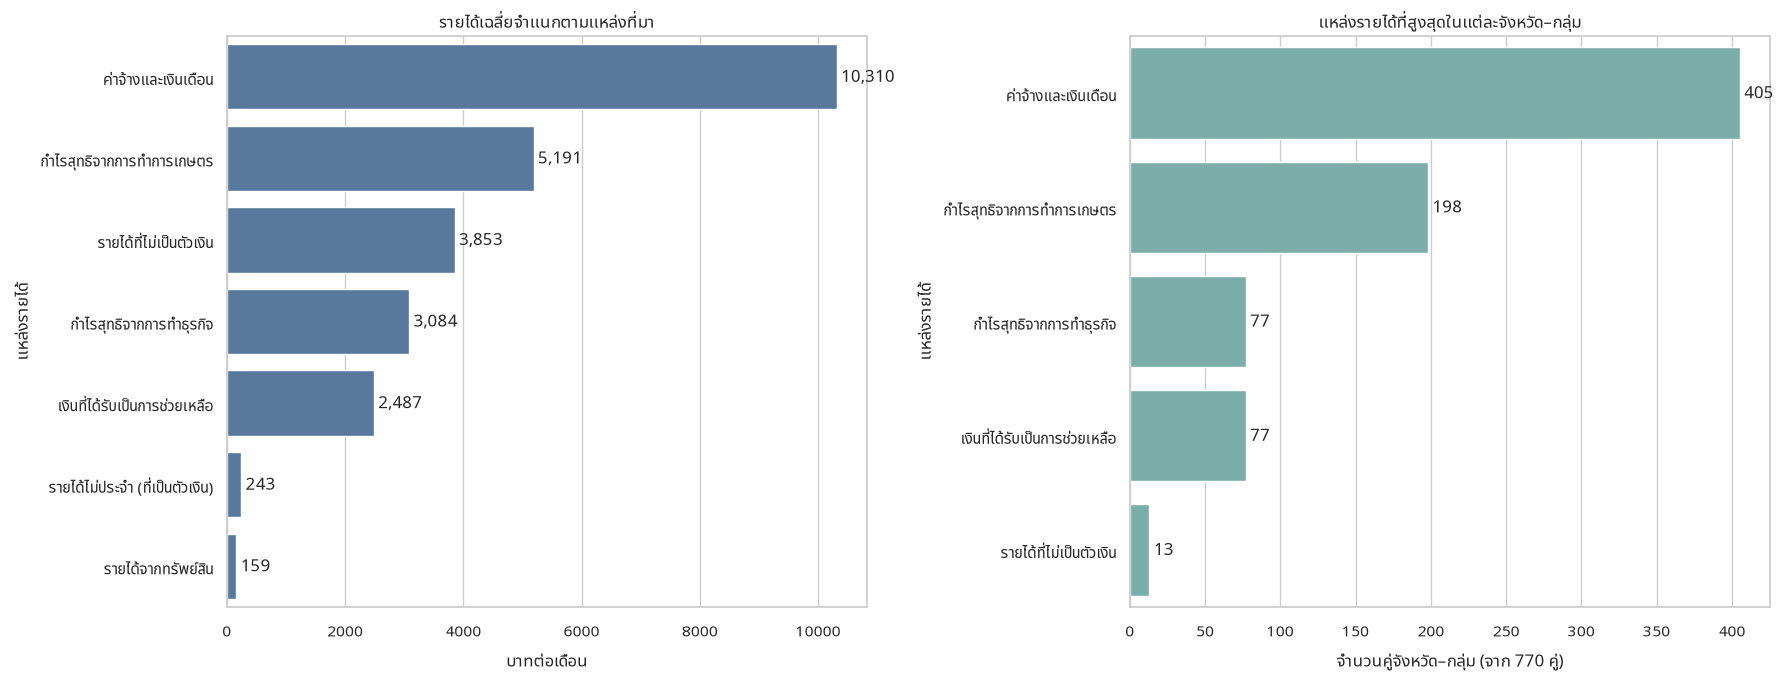

In [2]:
GROUP_KEYS = ['province', 'soc_eco_class1', 'soc_eco_class2']
INCOME_COMPONENTS = [
    'ค่าจ้างและเงินเดือน',
    'กำไรสุทธิจากการทำธุรกิจ',
    'กำไรสุทธิจากการทำการเกษตร',
    'เงินที่ได้รับเป็นการช่วยเหลือ',
    'รายได้จากทรัพย์สิน',
    'รายได้ที่ไม่เป็นตัวเงิน',
    'รายได้ไม่ประจำ (ที่เป็นตัวเงิน)',
]

income_total = income_source.loc[
    income_source['source_income3'] == 'รายได้ทั้งสิ้นต่อเดือน',
    GROUP_KEYS + ['value'],
].copy()
income_total.rename(columns={'value': 'income_total_baht'}, inplace=True)

income_components = income_source.loc[
    income_source['source_income3'].isin(INCOME_COMPONENTS),
    GROUP_KEYS + ['source_income3', 'value'],
].copy()

income_sum = income_components.groupby(GROUP_KEYS, as_index=False)['value'].sum()
income_sum.rename(columns={'value': 'component_total_baht'}, inplace=True)
income_check = income_total.merge(income_sum, on=GROUP_KEYS, validate='one_to_one')
income_check['difference_baht'] = income_check['income_total_baht'] - income_check['component_total_baht']

income_wide = income_components.pivot(index=GROUP_KEYS, columns='source_income3', values='value').reset_index()
income_wide.columns.name = None
income_wide['largest_income_source'] = income_wide[INCOME_COMPONENTS].idxmax(axis=1)

mean_income_by_source = income_components.groupby('source_income3', as_index=False)['value'].mean()
mean_income_by_source = mean_income_by_source.sort_values('value', ascending=False)
largest_income_source_count = income_wide['largest_income_source'].value_counts()
largest_income_source_count = largest_income_source_count.rename_axis('source_income3').reset_index(name='province_group_count')

assert len(income_total) == 770
assert len(income_components) == 5_390
assert income_check['difference_baht'].abs().max() <= 2

print('Mean income component across 770 province–group observations:')
print(mean_income_by_source.round(2).to_string(index=False))
print()
print('Largest source in each province–group observation:')
print(largest_income_source_count.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=mean_income_by_source, x='value', y='source_income3', ax=axes[0], color='#4C78A8', errorbar=None)
axes[0].set_title('รายได้เฉลี่ยจำแนกตามแหล่งที่มา')
axes[0].set_xlabel('บาทต่อเดือน')
axes[0].set_ylabel('แหล่งรายได้')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}', padding=3)

sns.barplot(data=largest_income_source_count, x='province_group_count', y='source_income3', ax=axes[1], color='#72B7B2', errorbar=None)
axes[1].set_title('แหล่งรายได้ที่สูงสุดในแต่ละจังหวัด–กลุ่ม')
axes[1].set_xlabel('จำนวนคู่จังหวัด–กลุ่ม (จาก 770 คู่)')
axes[1].set_ylabel('แหล่งรายได้')
axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', padding=3)
plt.tight_layout()
plt.show()

## 2. วัตถุประสงค์ของหนี้สินระดับจังหวัด

เปรียบเทียบหนี้สินเฉลี่ยต่อครัวเรือน 6 วัตถุประสงค์ในคู่จังหวัด–กลุ่มสถานะทางเศรษฐสังคมชุดเดียวกัน

Mean debt component across 770 province–group observations:
                    purpose_source_bor     value
ใช้จ่ายอุปโภค บริโภคอื่น ๆ ในครัวเรือน 75,506.10
    ใช้ซื้อ/เช่าซื้อบ้านและ/หรือที่ดิน 52,341.46
                       ใช้ในการทำเกษตร 44,848.01
                      ใช้ในการทำธุรกิจ 15,457.98
                         ใช้ในการศึกษา  2,767.58
                            หนี้อื่น ๆ  1,384.29

Largest debt purpose in each province–group observation:
                    purpose_source_bor  province_group_count
ใช้จ่ายอุปโภค บริโภคอื่น ๆ ในครัวเรือน                   392
    ใช้ซื้อ/เช่าซื้อบ้านและ/หรือที่ดิน                   181
                       ใช้ในการทำเกษตร                   163
                      ใช้ในการทำธุรกิจ                    32
                            หนี้อื่น ๆ                     2


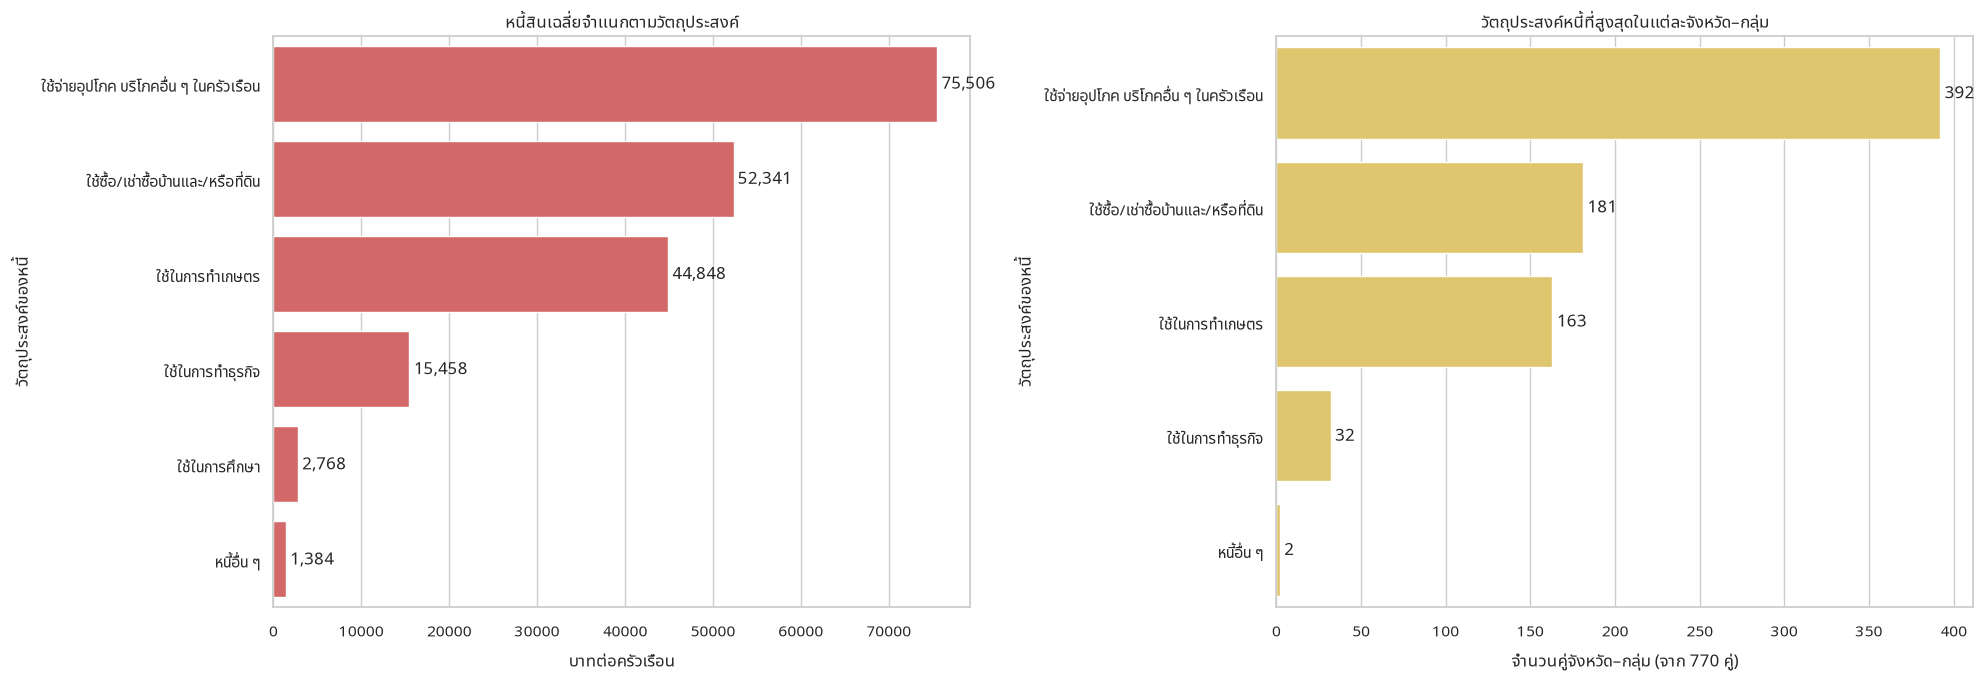

In [3]:
DEBT_PURPOSES = [
    'ใช้ซื้อ/เช่าซื้อบ้านและ/หรือที่ดิน',
    'ใช้ในการศึกษา',
    'ใช้จ่ายอุปโภค บริโภคอื่น ๆ ในครัวเรือน',
    'ใช้ในการทำธุรกิจ',
    'ใช้ในการทำเกษตร',
    'หนี้อื่น ๆ',
]

debt_total = debt_purpose_province.loc[
    debt_purpose_province['purpose_source_bor'] == 'จำนวนหนี้สินเฉลี่ยต่อครัวเรือน',
    GROUP_KEYS + ['value'],
].copy()
debt_total.rename(columns={'value': 'debt_total_baht'}, inplace=True)

debt_components = debt_purpose_province.loc[
    (debt_purpose_province['hhdebt_totaldebt'] == 'จำนวนหนี้สินเฉลี่ยต่อครัวเรือน')
    & (debt_purpose_province['hhdebt_totaldebt_purpose_source'] == 'จำแนกตามวัตถุประสงค์')
    & (debt_purpose_province['purpose_source_bor'].isin(DEBT_PURPOSES)),
    GROUP_KEYS + ['purpose_source_bor', 'value'],
].copy()

debt_sum = debt_components.groupby(GROUP_KEYS, as_index=False)['value'].sum()
debt_sum.rename(columns={'value': 'component_total_baht'}, inplace=True)
debt_check = debt_total.merge(debt_sum, on=GROUP_KEYS, validate='one_to_one')
debt_check['difference_baht'] = debt_check['debt_total_baht'] - debt_check['component_total_baht']

debt_wide = debt_components.pivot(index=GROUP_KEYS, columns='purpose_source_bor', values='value').reset_index()
debt_wide.columns.name = None
debt_wide['largest_debt_purpose'] = debt_wide[DEBT_PURPOSES].idxmax(axis=1)

mean_debt_by_purpose = debt_components.groupby('purpose_source_bor', as_index=False)['value'].mean()
mean_debt_by_purpose = mean_debt_by_purpose.sort_values('value', ascending=False)
largest_debt_purpose_count = debt_wide['largest_debt_purpose'].value_counts()
largest_debt_purpose_count = largest_debt_purpose_count.rename_axis('purpose_source_bor').reset_index(name='province_group_count')

assert len(debt_total) == 770
assert len(debt_components) == 4_620
assert debt_check['difference_baht'].abs().max() <= 2

print('Mean debt component across 770 province–group observations:')
print(mean_debt_by_purpose.round(2).to_string(index=False))
print()
print('Largest debt purpose in each province–group observation:')
print(largest_debt_purpose_count.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.barplot(data=mean_debt_by_purpose, x='value', y='purpose_source_bor', ax=axes[0], color='#E45756', errorbar=None)
axes[0].set_title('หนี้สินเฉลี่ยจำแนกตามวัตถุประสงค์')
axes[0].set_xlabel('บาทต่อครัวเรือน')
axes[0].set_ylabel('วัตถุประสงค์ของหนี้')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}', padding=3)

sns.barplot(data=largest_debt_purpose_count, x='province_group_count', y='purpose_source_bor', ax=axes[1], color='#F2CF5B', errorbar=None)
axes[1].set_title('วัตถุประสงค์หนี้ที่สูงสุดในแต่ละจังหวัด–กลุ่ม')
axes[1].set_xlabel('จำนวนคู่จังหวัด–กลุ่ม (จาก 770 คู่)')
axes[1].set_ylabel('วัตถุประสงค์ของหนี้')
axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', padding=3)
plt.tight_layout()
plt.show()

## 3. วัตถุประสงค์และประเภทหนี้ระดับประเทศ

ส่วนนี้ใช้จำนวนครัวเรือนจากตาราง SES เพื่อให้เห็นภาพระดับประเทศ โดยผลรวมตามวัตถุประสงค์อาจมีการนับซ้ำระหว่างหมวด

National debt-purpose records; categories may overlap:
                      Purpose_borrow   value
ใช้จ่ายอุปโภคบริโภคอื่นๆ ในครัวเรือน 8342871
                  ใช้ในการทำการเกษตร 2856377
  ใช้ซื้อ/เช่าซื้อบ้านและ/หรือที่ดิน 1669459
                    ใช้ในการทำธุรกิจ 1064819
                       ใช้ในการศึกษา  437056
                               อื่นๆ   65819

National debt types:
              Type_debt    value
 มีหนี้ในระบบอย่างเดียว 10613594
มีหนี้นอกระบบอย่างเดียว   548804
 มีหนี้ทั้งในและนอกระบบ   309774


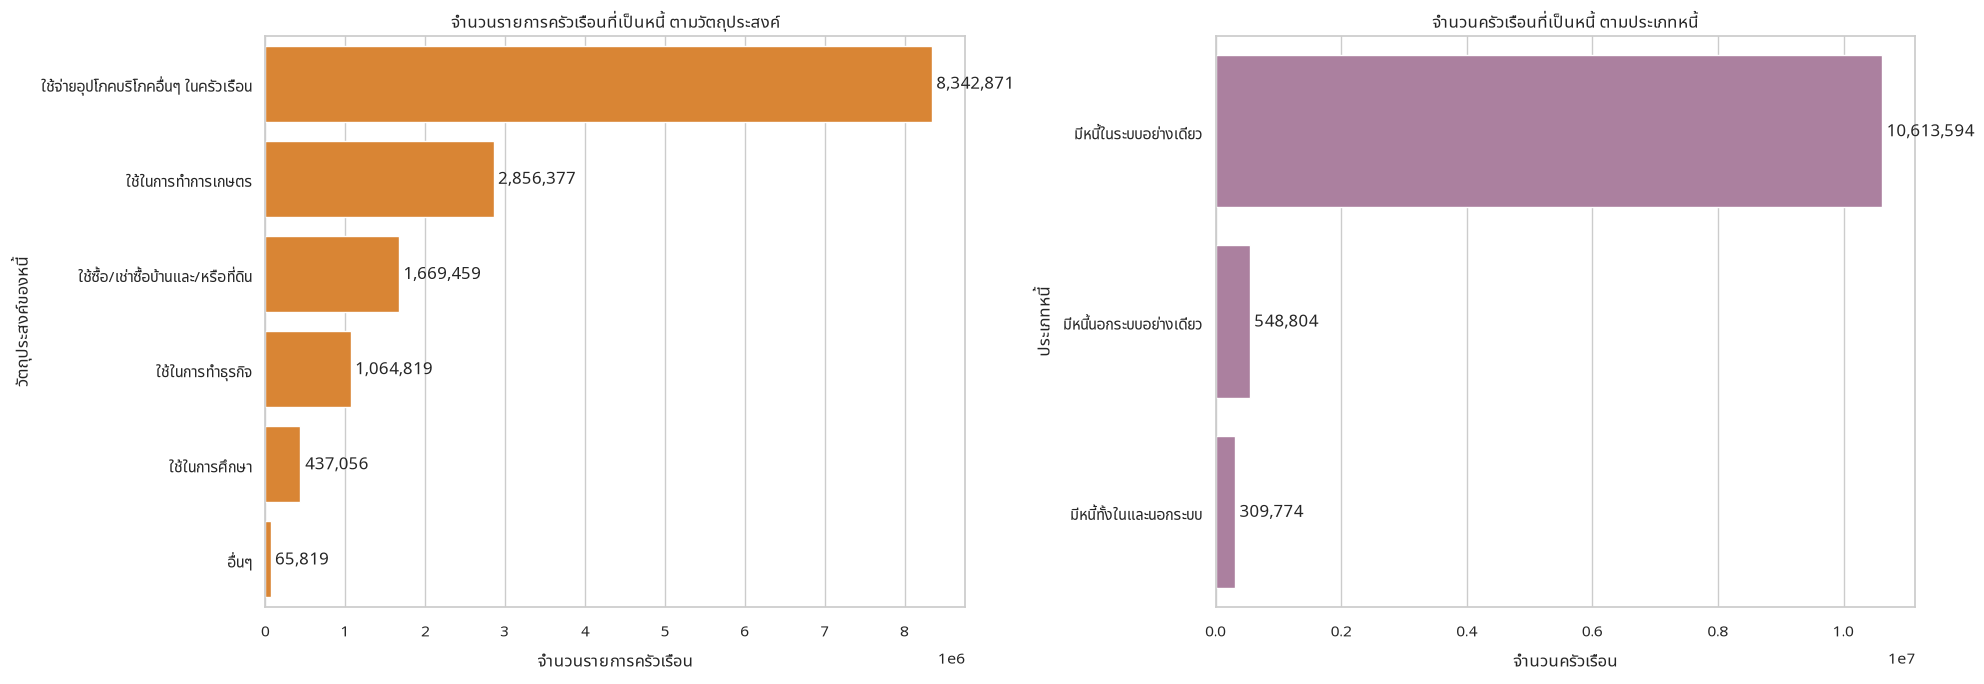

In [4]:
for column in ['Region', 'Area', 'Source_loan', 'Purpose_borrow']:
    debt_purpose_counts[column] = debt_purpose_counts[column].astype(str).str.strip()

national_purpose_rows = debt_purpose_counts.loc[
    (debt_purpose_counts['Region'] == 'ทั่วราชอาณาจักร')
    & (debt_purpose_counts['Area'] == 'รวม')
    & (debt_purpose_counts['Source_loan'] != 'รวม')
    & (debt_purpose_counts['Purpose_borrow'] != 'รวม'),
    ['Source_loan', 'Purpose_borrow', 'value'],
].copy()

national_purpose_counts = national_purpose_rows.groupby('Purpose_borrow', as_index=False)['value'].sum()
national_purpose_counts = national_purpose_counts.sort_values('value', ascending=False)

for column in ['Region', 'Area', 'Type_debt']:
    debt_type_counts[column] = debt_type_counts[column].astype(str).str.strip()

national_debt_types = debt_type_counts.loc[
    (debt_type_counts['Region'] == 'ทั่วราชอาณาจักร')
    & (debt_type_counts['Area'] == 'รวม')
    & (debt_type_counts['Type_debt'] != 'รวม'),
    ['Type_debt', 'value'],
].copy()
national_debt_types = national_debt_types.sort_values('value', ascending=False)

assert len(national_purpose_counts) == 6
assert len(national_debt_types) == 3

print('National debt-purpose records; categories may overlap:')
print(national_purpose_counts.to_string(index=False))
print()
print('National debt types:')
print(national_debt_types.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.barplot(data=national_purpose_counts, x='value', y='Purpose_borrow', ax=axes[0], color='#F58518', errorbar=None)
axes[0].set_title('จำนวนรายการครัวเรือนที่เป็นหนี้ ตามวัตถุประสงค์')
axes[0].set_xlabel('จำนวนรายการครัวเรือน')
axes[0].set_ylabel('วัตถุประสงค์ของหนี้')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}', padding=3)

sns.barplot(data=national_debt_types, x='value', y='Type_debt', ax=axes[1], color='#B279A2', errorbar=None)
axes[1].set_title('จำนวนครัวเรือนที่เป็นหนี้ ตามประเภทหนี้')
axes[1].set_xlabel('จำนวนครัวเรือน')
axes[1].set_ylabel('ประเภทหนี้')
axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', padding=3)
plt.tight_layout()
plt.show()

## 4. สรุปผล

คำตอบจากส่วนรายได้และหนี้ระดับจังหวัด–กลุ่ม เป็นค่าเฉลี่ยของคู่จังหวัด–กลุ่ม ขณะที่คำตอบระดับประเทศใช้จำนวนรายการครัวเรือนจากตาราง SES จึงควรอ่านแยกตามระดับข้อมูล

In [5]:
largest_income_component = mean_income_by_source.iloc[0]
most_common_income_source = largest_income_source_count.iloc[0]
largest_debt_component = mean_debt_by_purpose.iloc[0]
most_common_debt_purpose = largest_debt_purpose_count.iloc[0]
largest_national_purpose = national_purpose_counts.iloc[0]
largest_debt_type = national_debt_types.iloc[0]

print('Key findings:')
print(f'- Largest mean income component: {largest_income_component["source_income3"]} ({largest_income_component["value"]:,.0f} baht/month)')
print(f'- Most common largest income source: {most_common_income_source["source_income3"]} ({most_common_income_source["province_group_count"]:,} of 770 province–group observations)')
print(f'- Largest mean debt purpose: {largest_debt_component["purpose_source_bor"]} ({largest_debt_component["value"]:,.0f} baht/household)')
print(f'- Most common largest debt purpose: {most_common_debt_purpose["purpose_source_bor"]} ({most_common_debt_purpose["province_group_count"]:,} of 770 province–group observations)')
print(f'- Largest national debt-purpose record: {largest_national_purpose["Purpose_borrow"]} ({largest_national_purpose["value"]:,.0f} records; categories can overlap)')
print(f'- Most common national debt type: {largest_debt_type["Type_debt"]} ({largest_debt_type["value"]:,.0f} households)')

Key findings:
- Largest mean income component: ค่าจ้างและเงินเดือน (10,310 baht/month)
- Most common largest income source: ค่าจ้างและเงินเดือน (405 of 770 province–group observations)
- Largest mean debt purpose: ใช้จ่ายอุปโภค บริโภคอื่น ๆ ในครัวเรือน (75,506 baht/household)
- Most common largest debt purpose: ใช้จ่ายอุปโภค บริโภคอื่น ๆ ในครัวเรือน (392 of 770 province–group observations)
- Largest national debt-purpose record: ใช้จ่ายอุปโภคบริโภคอื่นๆ ในครัวเรือน (8,342,871 records; categories can overlap)
- Most common national debt type: มีหนี้ในระบบอย่างเดียว (10,613,594 households)
